# 1. Introdução

# 2. Contexto do Problema de Negócio

# 3. Descrição da Base de Dados

# 4. Variável Target

# 5. Importação de Bibliotecas e Configurações Iniciais

In [1]:
# BIBLIOTECAS IMPORTADAS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import scipy.stats as sts

# 6. Carregamento dos Dados

In [2]:
# CARREGAMENTO DO DATASET
application_train = pd.read_csv('../data/application_train.csv', encoding = 'iso-8859-1')

# 7. Visão Geral do Dados

In [3]:
print('Formato do dataset (LinhasxColunas):{}\n'.format(application_train.shape))
print('Tipo das variáveis presentes no dataset: \n{}\n'.format(application_train.dtypes.unique()))
print('Informações Geral do dataset:')
application_train.info()
application_train.head(10)

Formato do dataset (LinhasxColunas):(307511, 122)

Tipo das variáveis presentes no dataset: 
[dtype('int64') dtype('O') dtype('float64')]

Informações Geral do dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
5,100008,0,Cash loans,M,N,Y,0,99000.0,490495.5,27517.5,...,0,0,0,0,0.0,0.0,0.0,0.0,1.0,1.0
6,100009,0,Cash loans,F,Y,Y,1,171000.0,1560726.0,41301.0,...,0,0,0,0,0.0,0.0,0.0,1.0,1.0,2.0
7,100010,0,Cash loans,M,Y,Y,0,360000.0,1530000.0,42075.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
8,100011,0,Cash loans,F,N,Y,0,112500.0,1019610.0,33826.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
9,100012,0,Revolving loans,M,N,Y,0,135000.0,405000.0,20250.0,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


# 8. Análise da Variável Target

Tipo do TARGET: int64
Quantidade total do TARGET: 307,511.00
Percentil das categorias do Target: TARGET
0    91.927118
1     8.072882
Name: proportion, dtype: float64


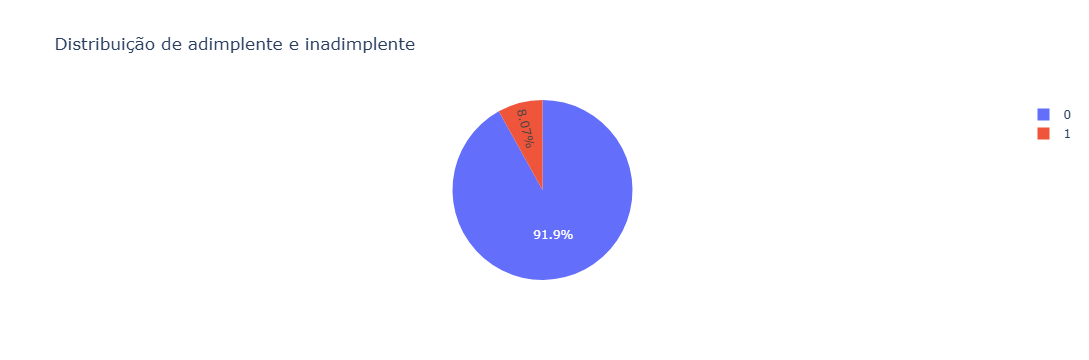

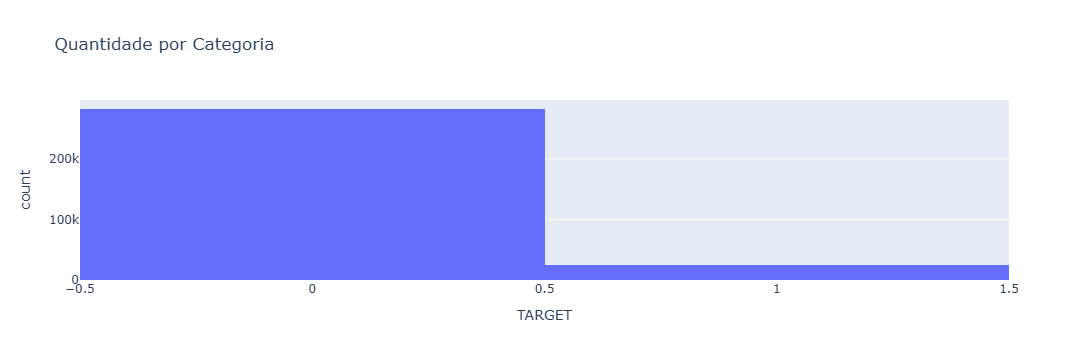

In [4]:
print('Tipo do TARGET: {}'.format(application_train['TARGET'].dtype))
print('Quantidade total do TARGET: {:,.2f}'.format(application_train['TARGET'].value_counts().sum()))
print('Percentil das categorias do Target: {}'.format(application_train['TARGET'].value_counts(normalize = True) * 100))
display(px.pie(application_train, 'TARGET', title = 'Distribuição de adimplente e inadimplente'))
display(px.histogram(application_train, x = 'TARGET', title = 'Quantidade por Categoria'))

## Interpretação da Variável TARGET

A análise da variável TARGET evidencia um forte desbalanceamento entre as classes.
Do total de aproximadamente 307 mil registros, cerca de 91,9% correspondem a clientes
adimplentes (TARGET = 0), enquanto aproximadamente 8,1% representam clientes
inadimplentes (TARGET = 1).

Esse comportamento é esperado em bases de dados utilizadas para concessão de crédito,
uma vez que eventos de inadimplência tendem a ser significativamente menos frequentes
do que pagamentos em dia.

O forte desbalanceamento observado indica que métricas tradicionais como acurácia
não serão adequadas para avaliar o desempenho dos modelos preditivos.
Dessa forma, será necessário utilizar métricas mais apropriadas ao contexto de
risco de crédito, como AUC-ROC, Recall da classe inadimplente e métricas focadas
na separação entre bons e maus pagadores.

# 9. Análise de Valores Ausentes (Missing Values)

## Visão Global (Macro)

In [5]:
# EXTRAI AS FEATURES COM QUALQUER VALORE NULO PRESENTE 
application_null = application_train.loc[:, application_train.isna().any()]

# EXTRAI OS REGISTROS DAS FEATURES ONDE POSSUI VALOR NULO PRESENTE
missing_value = application_null[application_null.isna().any(axis = 1)]

# QUANTIDADE TOTAL DE REGISTROS, QUANTIDADE DE VALORES NULOS, PROPORÇÃO DE NULOS
total_registros = len(application_train)
total_nulos = missing_value.isna().sum().sum()
proporcao_nulos = (missing_value.isna().sum().sum() / missing_value.size) * 100


# RESULTADOS ALCANÇADOS
print('Quantidade Total Registros: {:,.2f}'.format(total_registros))
print('Quantidade de Valores Nulos: {:,.2f}'.format(total_nulos))
print('Proporção de Valores Nulos: {:.2f}%'.format(proporcao_nulos))

Quantidade Total Registros: 307,511.00
Quantidade de Valores Nulos: 9,152,465.00
Proporção de Valores Nulos: 45.70%


### Insigths dos valores ausentes (Visão Macro)
Observa-se que o dataset apresente um volume elevado de valores ausentes. Do total de aproximadamente 307 mil registros e 122 variaveis,
cerca de 45% das observações póssiveis encontram-se com valores nulos.

Esse comportamento é esperado em bases de risco de crédito, uma vez que nem todas as informações são aplicáveis a todos os perfis de cliente ou estão disponíveis no momento da concesão

## Visão micro dos valores ausentes

In [6]:
# CRIA O DATAFRAME COM O PERCENTUAL E VARIAVL
missing_df = application_train.isna().mean().sort_values(ascending=False).reset_index()
missing_df.columns = ['Variavel', 'Percentual_Nulos']

# CRIA O DATAFRAME COM A QUANTIDADE DE NULOS
soma_nulos = application_train.isna().sum()
coluna_nulos = soma_nulos.to_frame().reset_index()
coluna_nulos.columns = ['Variavel', 'Quantidade_Nulos']

# JUNTA OS DOIS DATAFRAMES PELA COLUNA 'VARIAVEL'
dataset_final = pd.merge(coluna_nulos, missing_df, on='Variavel')

# FILTRA PARA TRAZER APENAS QUEM TEM NULOS E ORDENA DO MAIOR PARA O MENOR
dataset_final = dataset_final[dataset_final['Quantidade_Nulos'] > 0]
dataset_final = dataset_final.sort_values(by='Quantidade_Nulos', ascending=False).reset_index(drop=True)

# EXIBE O RESULTADO FINAL
dataset_final


,Variavel,Quantidade_Nulos,Percentual_Nulos
0,COMMONAREA_MEDI,214865,0.698723
1,COMMONAREA_AVG,214865,0.698723
2,COMMONAREA_MODE,214865,0.698723
3,NONLIVINGAPARTMENTS_MEDI,213514,0.694330
4,NONLIVINGAPARTMENTS_MODE,213514,0.694330
...,...,...,...
62,EXT_SOURCE_2,660,0.002146
63,AMT_GOODS_PRICE,278,0.000904
64,AMT_ANNUITY,12,0.000039
65,CNT_FAM_MEMBERS,2,0.000007


In [7]:
# PERCENTUAL DE MISSING 0% - 5%
baixo_impacto = dataset_final[dataset_final['Percentual_Nulos'] <= 0.05].reset_index(drop = True)
baixo_impacto

# PERCENTUAL DE MISSING 5% - 30%
atencao = dataset_final[(dataset_final['Percentual_Nulos'] > 0.05) & (dataset_final['Percentual_Nulos'] <= 0.30)].reset_index(drop = True)
atencao

# PERCENTUAL DE MISSING 30% - 60%
alto_risco = dataset_final[(dataset_final['Percentual_Nulos'] > 0.30) & (dataset_final['Percentual_Nulos'] <= 0.60)].reset_index(drop = True)
alto_risco

# PERCENTUAL DE MISSING >= 60%
candidato_descarte  = dataset_final[dataset_final['Percentual_Nulos'] >= 0.60].reset_index(drop = True)
candidato_descarte

print('Quantidades total de missing em cada faixa: \nBaixo_Risco: {} \nAtenção: {}\nAlto_Risco: {}\nCandidato a Descarte: {}\n'.format(len(baixo_impacto),len(atencao), len(alto_risco), len(candidato_descarte) ))

Quantidades total de missing em cada faixa: 
Baixo_Risco: 10 
Atenção: 7
Alto_Risco: 33
Candidato a Descarte: 17



### Insights dos valores missing (visão micro)

Observado na análise mais detalhada de missing values, as features com qualquer valor missing presente em seus registros foram divididas em 4 grupos distintos, esses grupos tem como caracteristica, classificar a variavel baseado na sua porcentagem de nulos proporcional ao total de observações
Do total de 67 features com valores missing presente em seus registros, 
- **Baixo Risco (0% - 5%)**: 10 Features
- **Atenção (5% - 30%)**: 7 Features
- **Alto Risco (30% - 60%)**: 33 Features
- **Candidato à Descarte (>= 60%)**: 17 Features

As faixas são definidas pela proporção de valores nulos que cada feature tem, sendo:
- **Baixo Risco**: Missing Pontual, Pouco Impacto na Modelagem, Tratamento simples no futuro
- **Atenção**: Missing Relevante, Exige Análise individual no feature engineering, Podem Carregar alguma informação 
- **Alto Risco**: Missing elevado, muitas vezes ocasionado à não aplicabilidade, Avaliação cuidadosa antes de manter
- **Candidato à Descarte**: Missing Extremo, Alto rísco de Ruído, Só mantidas se forem claramente informativas, caso contrário, forte candidata a exclusão.


**OWN_CAR_AGE** - Candidato a Descarte
- Essa variavel apresenta elevado percentual de valores ausentes devido à não posse de veículo por parte dos clientes. Embora o missing seja informativo, o uso direto da variável pode gerar viés, sendo mais adequado explorar a informação por meio de uma flag indicativa de posse de veículo. Será descartada ou transformada em flag

**APARTAMENTS_MODE** - Alto Risco:
- O elevado percentual de valores ausentes está associado tanto à não posse de imóvel quanto à ausência de informação declarada. Apesar do alto nível de missing, a variável pode carregar sinal socioeconômico relevante, devendo ser avaliada com cautela na etapa de feature engeneering. Será mantida para avaliação futura, possivelmente como flag.

**AMT_REQ_CREDIT_BUREAU_WEEK** - Atenção
- A ausência de registros pode indicar inexistência de consultas recentes ao birô de crédito, o quer por si só pode ser informativo. Trata-se de uma variável potencialmente relevante para o risco de crédito, devendo ser mantida e analisada em conjunto com outras variáveis de histórico extermo. Manter, missing pode ser informativo.

**Diretrizes para o Pipeline**
- Features pertencente ao grupo 'Candidato a Descarte' -> serão avaliadas paa serem descartadas
- Missimg por não aplicabilidade -> Criação de flags
- Missing potencialmente informativo -> manter e tratar
- Estratégias de imputação -> Definidas na fase de modelagem

# 10. Análise de Variáveis Numéricas

## Distribuição Geral das Variáveis Numéricas (Visão Macro)

In [8]:
num_int = (len(application_train.select_dtypes(['int64']).columns))
num_float= (len(application_train.select_dtypes(['float64']).columns))
print('Quantidade de colunas numéricas tipo inteiro: {}\nQuantidade de colunas numéricas tipo real: {}\nQuantidade Total de colunas numéricas: {}'
     .format(num_int, num_float, num_int + num_float))

Quantidade de colunas numéricas tipo inteiro: 41
Quantidade de colunas numéricas tipo real: 65
Quantidade Total de colunas numéricas: 106


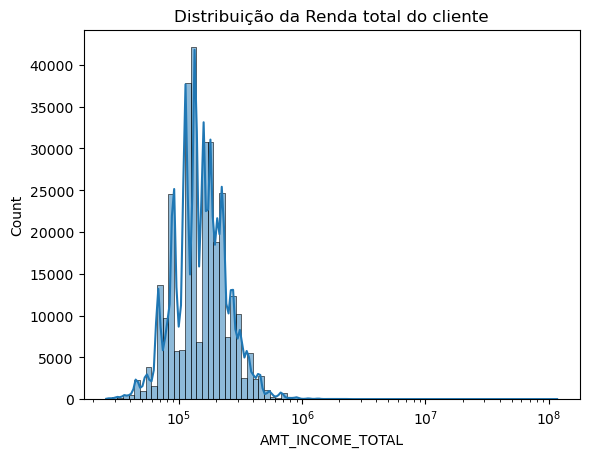

In [9]:
renda_dist = sns.histplot(application_train, x = 'AMT_INCOME_TOTAL', kde= True, bins = 80, stat = 'count', log_scale = True)
renda_dist.set_title('Distribuição da Renda total do cliente')
plt.show()
px.box(application_train, x = 'AMT_INCOME_TOTAL', title = 'Outliers presentes na Renda total do cliente')

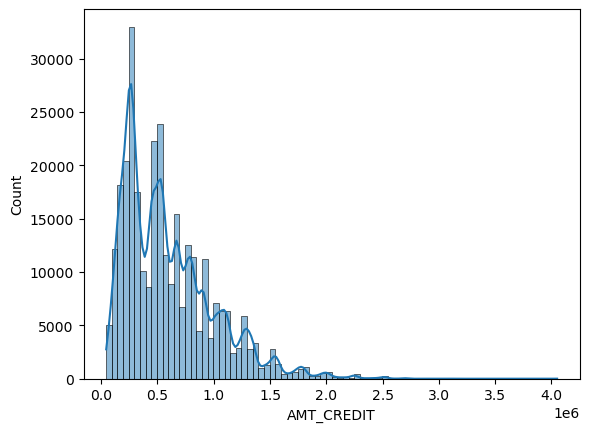

In [10]:
credito_dist = sns.histplot(application_train, x = 'AMT_CREDIT', kde= True, bins = 80, stat = 'count')
renda_dist.set_title('Distribuição do Valor do Crédito')
plt.show()
px.box(application_train, x = 'AMT_CREDIT', title = 'Outliers presentes no Valor do Crédito')

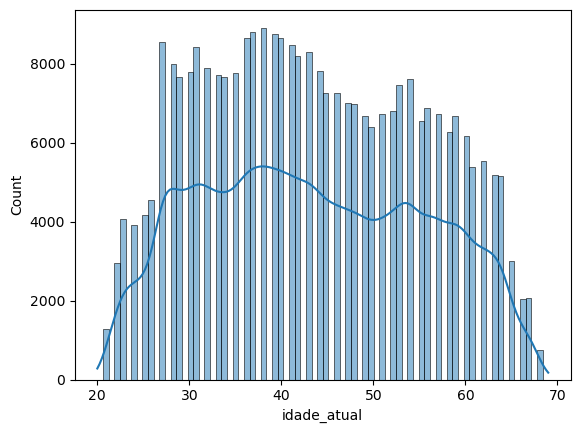

In [11]:
# Força os dias a ficarem positivos antes de calcular a idade
application_train['idade_atual'] = (application_train['DAYS_BIRTH'].abs() // 365.25).astype(int)
idade_dist = sns.histplot(application_train, x = 'idade_atual', kde= True, bins = 80, stat = 'count')
renda_dist.set_title('Distribuição da Idade atual dos clientes')
plt.show()
px.box(application_train, x = 'idade_atual', title = 'Outliers presentes na idade atual dos clientes')

### Insights das Variáveis Numéricas (Visão Macro)

Observa-se que as variáveis numéricas analisadas apresentam comportamentos
heterogêneos, com distribuições assimétricas e presença de outliers,
característica comum em bases financeiras.

A renda total dos clientes apresenta concentração em determinadas faixas,
acompanhada por uma cauda longa à direita, indicando elevada dispersão e
presença de valores extremos. Esse comportamento é esperado em contextos
bancários, dado o perfil diverso dos clientes, não sendo identificada,
nesta etapa, a necessidade de exclusão ou tratamento específico desses outliers.

Comportamento semelhante é observado no valor do crédito concedido,
que também apresenta assimetria positiva e valores elevados no limite superior.
Esse padrão reflete a relação direta entre renda e capacidade de concessão de crédito.

A variável idade apresenta distribuição mais homogênea, sem evidência
de caudas extremas ou outliers relevantes, indicando estabilidade ao longo
das diferentes faixas etárias analisadas.

No total, foram identificadas 106 variáveis numéricas, sendo 41 do tipo inteiro (int)
e 65 do tipo contínuo (float).

## Variáveis Numéricas x TARGET (Visão Micro)

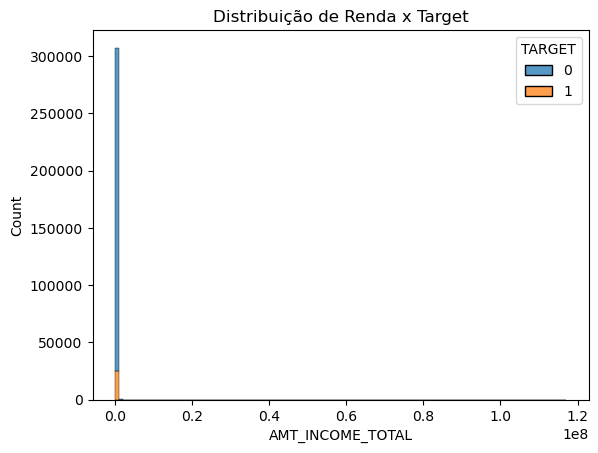

In [12]:
# Criando o gráfico com separação por cores
ax = sns.histplot(data= application_train, x ="AMT_INCOME_TOTAL", hue="TARGET", multiple="stack", bins = 120, stat = 'count')

# Configurando o título
ax.set_title("Distribuição de Renda x Target")

plt.show()


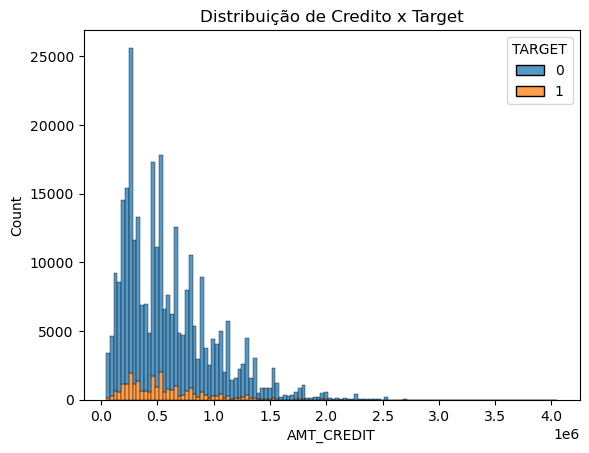

In [13]:
# Criando o gráfico com separação por cores
ax = sns.histplot(data= application_train, x ="AMT_CREDIT", hue="TARGET", multiple="stack", bins = 120, stat = 'count')
# Configurando o título
ax.set_title("Distribuição de Credito x Target")
plt.show()


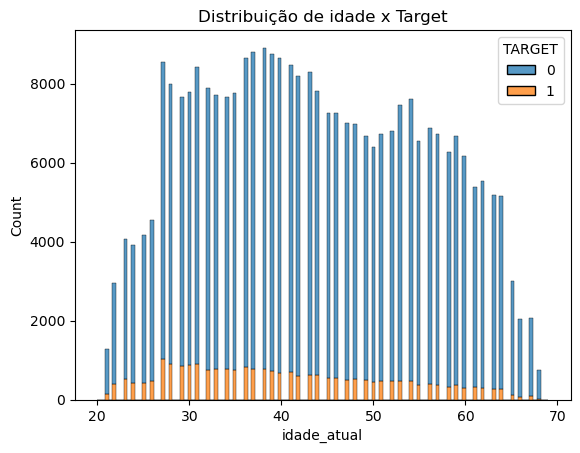

In [14]:
# Criando o gráfico com separação por cores
ax = sns.histplot(data= application_train, x ="idade_atual", hue="TARGET", multiple="stack", bins = 120)

# Configurando o título
ax.set_title("Distribuição de idade x Target")

plt.show()


### Insights das Variáveis Numéricas (Visão Micro)

Na análise da relação entre variáveis numéricas e a variável target,
observa-se comportamento distinto entre clientes adimplentes e inadimplentes.

Para a renda total, nota-se maior concentração de clientes adimplentes em faixas
mais elevadas de renda, enquanto a inadimplência se concentra de forma mais
expressiva nas faixas inferiores, sugerindo relação potencial entre menor renda
e maior risco de crédito.

Padrão semelhante é observado na análise do valor do crédito concedido,
em que clientes inadimplentes tendem a se concentrar em faixas de crédito menores.
Esse comportamento é consistente com políticas de concessão, nas quais limites
mais elevados estão associados a clientes com maior capacidade financeira.

A análise da variável idade indica a presença de inadimplentes em todas as faixas
etárias analisadas, sugerindo que a idade, isoladamente, não é suficiente para
diferenciar o risco de crédito, devendo ser considerada em conjunto com outras
variáveis do perfil do cliente.

# 11.  Análise das Variáveis Categóricas

O dataset apresenta um conjunto relevante de variáveis categóricas, relacionadas a características demográficas, socioeconômicas e operacionais dos clientes. Algumas dessas variáveis possuem baixa cardinalidade, enquanto outras apresentam um número elevado de categorias, o que exigirá um tratamento adequado nas próximas etapas.

In [15]:
# RETORNA O NUMERO DE VARIAVEIS CATEGÓRICAS NO DATASET
num_cat = len(application_train.select_dtypes(['object']).columns)

# CRIA UM NOVO DATASET SOMENTE COM AS VARIAVEIS CATEGÓRICAS
cat_app = application_train.select_dtypes(['object'])
print('Quantidade de variáveis do tipo object: {}'.format(num_cat))

# CRIA UM DATAFRAME COM A CONTAGEM DE CADA CATEGÓRIA NO DATASET
categorias_app = cat_app.nunique().reset_index(name='Quantidade_Categorias').rename(columns={'index': 'features'})
display(categorias_app)


Quantidade de variáveis do tipo object: 16


,features,Quantidade_Categorias
0,NAME_CONTRACT_TYPE,2
1,CODE_GENDER,3
2,FLAG_OWN_CAR,2
3,FLAG_OWN_REALTY,2
4,NAME_TYPE_SUITE,7
5,NAME_INCOME_TYPE,8
6,NAME_EDUCATION_TYPE,5
7,NAME_FAMILY_STATUS,6
8,NAME_HOUSING_TYPE,6
9,OCCUPATION_TYPE,18


## Distribuição das Variáveis Categorias (Visão Macro)

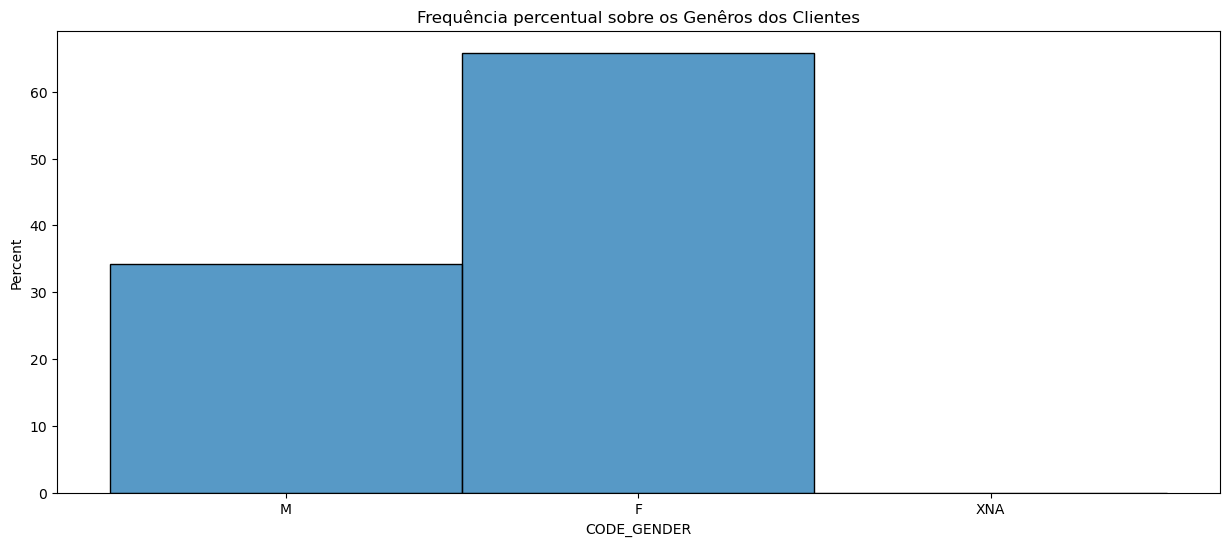

In [16]:
plt.figure(figsize = (15,6))
sns.histplot(application_train, x = 'CODE_GENDER', stat = 'percent')
plt.title('Frequência percentual sobre os Genêros dos Clientes');

Text(0.5, 1.0, 'Frequência a identificação do tipo de contrato')

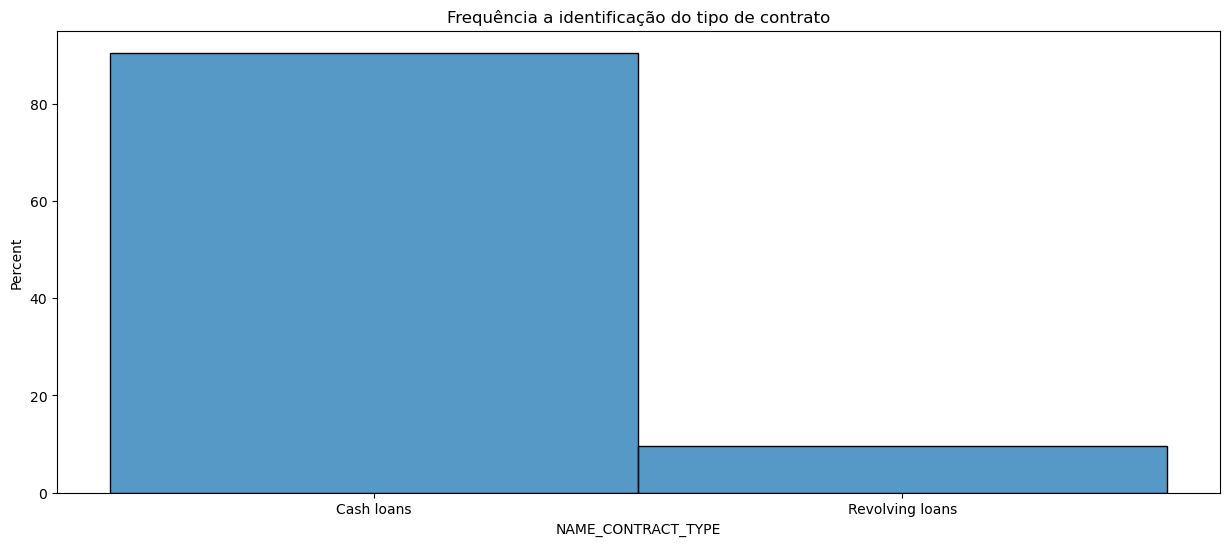

In [17]:
plt.figure(figsize = (15,6))
sns.histplot(application_train, x = 'NAME_CONTRACT_TYPE', stat = 'percent')
plt.title('Frequência a identificação do tipo de contrato')

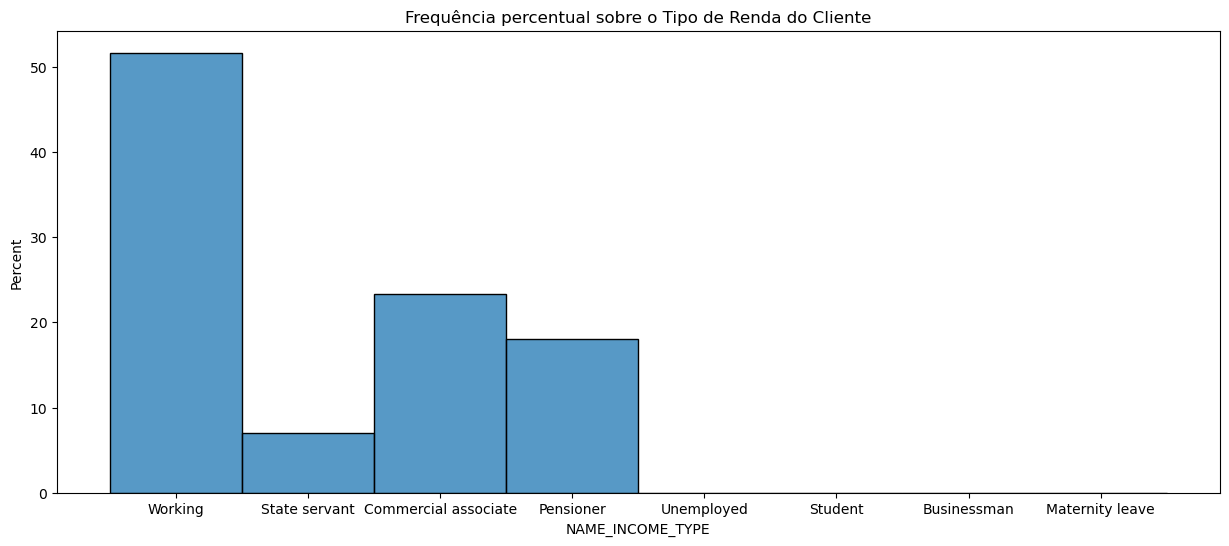

In [18]:
plt.figure(figsize = (15,6))
sns.histplot(application_train, x = 'NAME_INCOME_TYPE', stat = 'percent')
plt.title('Frequência percentual sobre o Tipo de Renda do Cliente');

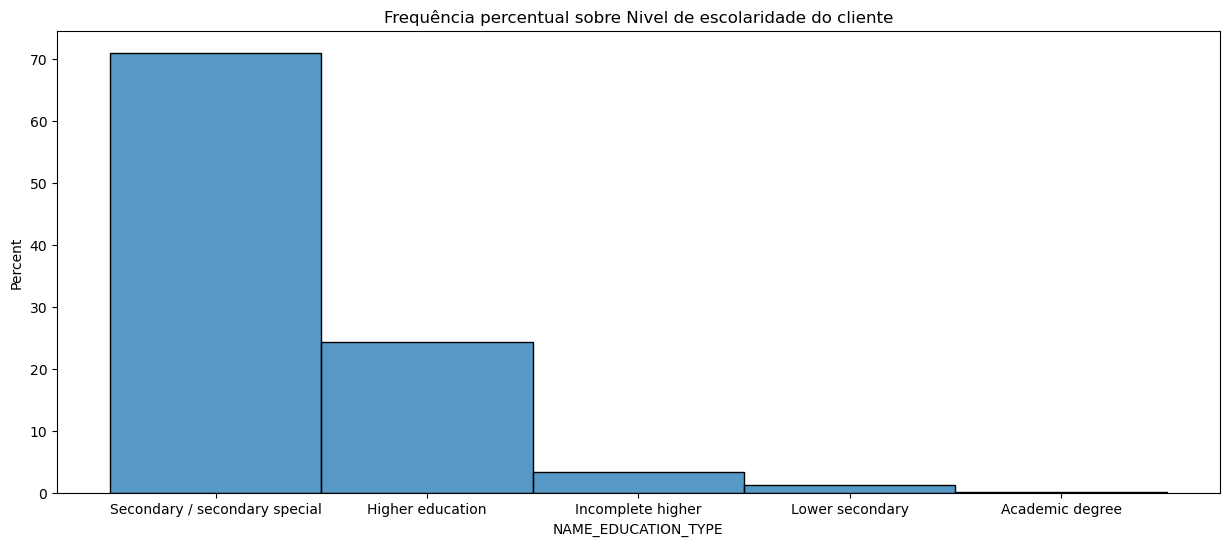

In [19]:
plt.figure(figsize = (15,6))
sns.histplot(application_train, x = 'NAME_EDUCATION_TYPE', stat = 'percent', log_scale = True)
plt.title('Frequência percentual sobre Nivel de escolaridade do cliente');

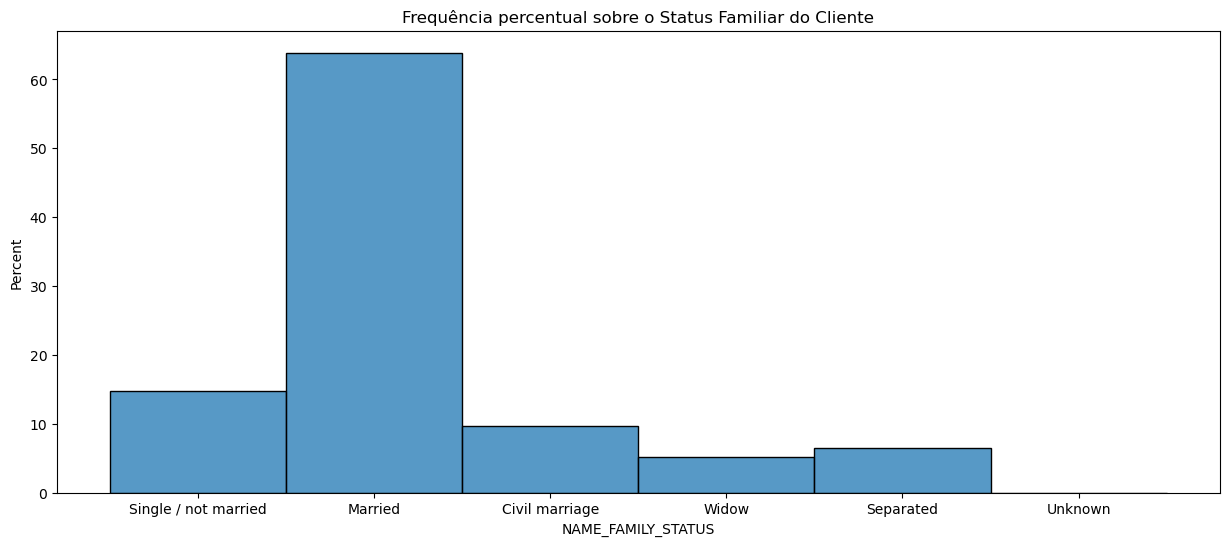

In [20]:
plt.figure(figsize = (15,6))
sns.histplot(application_train, x = 'NAME_FAMILY_STATUS', stat = 'percent', log_scale = True)
plt.title('Frequência percentual sobre o Status Familiar do Cliente');

### Insights da Análise de Variáveis Categóricas (Visão Macro)

A análise da distribuição das variáveis categóricas indica a presença de categorias dominantes em grande parte das features analisadas,
bem como categorias com baixa frequência. Esse comportamento é relevante para decisões futuras de encoding e possível agrupamento de categorias raras

## Variáveis Categóricas x TARGET (Visão Micro)

In [21]:
print('Observações por Categoria')
# DATASET CONTENDO SOMENTE AS FEATURES OBSERVADAS
cat_app2 = cat_app[['NAME_INCOME_TYPE','NAME_EDUCATION_TYPE','CODE_GENDER']]

# TRANSFORMA AS COLUNAS EM LINHAS
cat_empilhado = cat_app2.melt(var_name='Feature', value_name = 'Categoria')

# CONTA A QUANTIDADE DE CADA CATEGORIA ÚNICA NO DATASET
cat_contagem = cat_empilhado.value_counts(subset = ['Feature','Categoria']).reset_index(name = 'Observacoes')

# RENOMEIA AS COLUNAS DO DATASET
cat_contagem = cat_contagem.sort_values(by = ['Feature', 'Observacoes'], ascending = [True, False])

# VIZUALIZAR O RESULTADO E ORDENAR DO MENOR PARA O MAIO
display(cat_contagem)


Observações por Categoria


,Feature,Categoria,Observacoes
1,CODE_GENDER,F,202448
3,CODE_GENDER,M,105059
15,CODE_GENDER,XNA,4
0,NAME_EDUCATION_TYPE,Secondary / secondary special,218391
4,NAME_EDUCATION_TYPE,Higher education,74863
8,NAME_EDUCATION_TYPE,Incomplete higher,10277
9,NAME_EDUCATION_TYPE,Lower secondary,3816
10,NAME_EDUCATION_TYPE,Academic degree,164
2,NAME_INCOME_TYPE,Working,158774
5,NAME_INCOME_TYPE,Commercial associate,71617


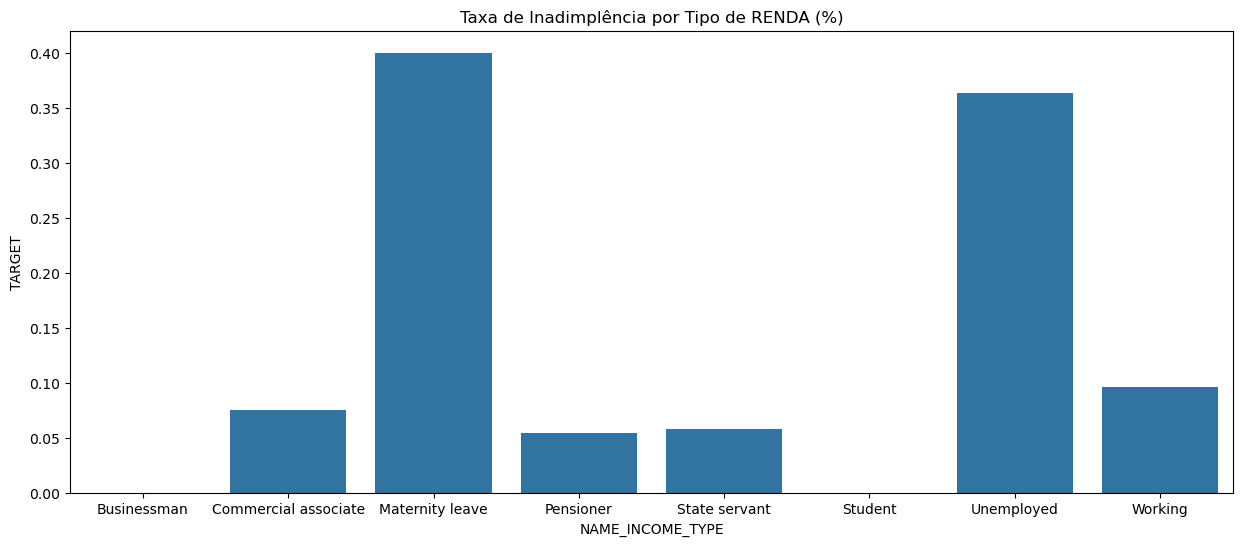

In [25]:
# GRÁFICO MONTANDO PARA REPRESENTARA PROPORÇÃO DE INADIMPLENTES POR CATEGORIA DA FEATURE NAME_INCOME_TYPE
plt.figure(figsize = (15,6))
taxa_inad = (application_train.groupby('NAME_INCOME_TYPE')['TARGET'].mean().reset_index())
taxa_inad
sns.barplot(taxa_inad, x= 'NAME_INCOME_TYPE', y = 'TARGET')
plt.title('Taxa de Inadimplência por Tipo de RENDA (%)');

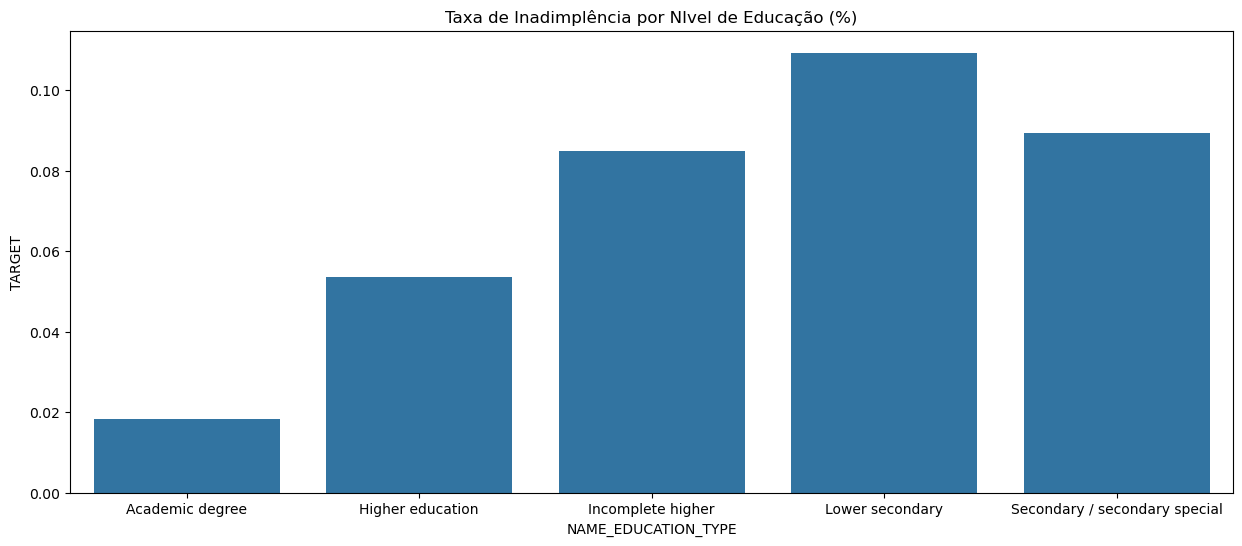

In [27]:
# GRÁFICO MONTANDO PARA REPRESENTARA PROPORÇÃO DE INADIMPLENTES POR CATEGORIA DA FEATURE NAME_EDUCATION_TYPE
plt.figure(figsize = (15,6))
taxa_inad = (application_train.groupby('NAME_EDUCATION_TYPE')['TARGET'].mean().reset_index())
taxa_inad
sns.barplot(taxa_inad, x= 'NAME_EDUCATION_TYPE', y = 'TARGET')
plt.title('Taxa de Inadimplência por NIvel de Educação (%)');

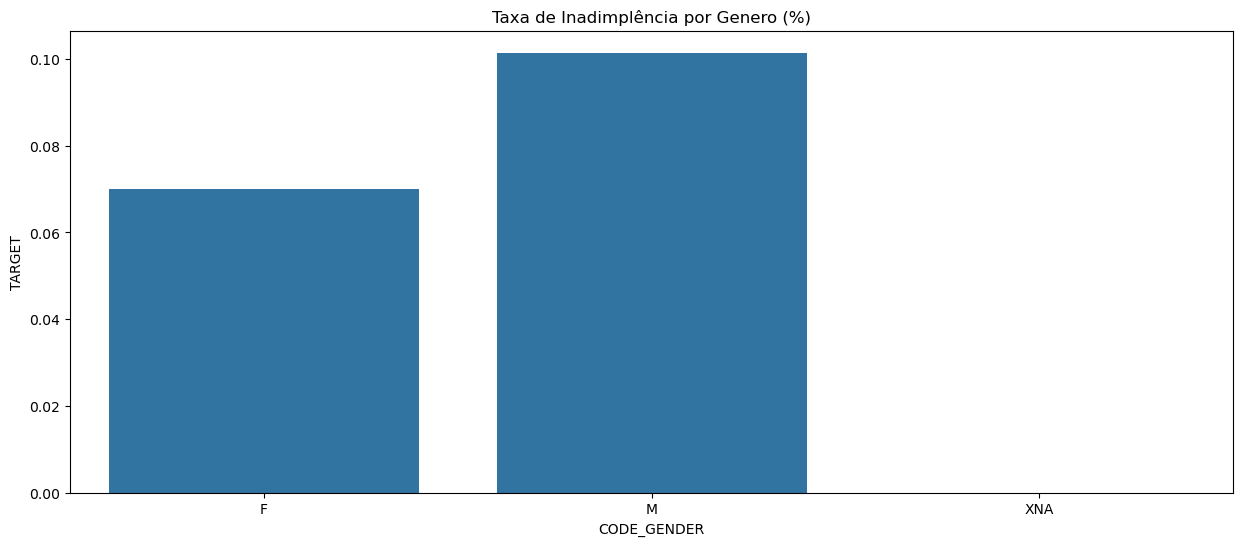

In [28]:
# GRÁFICO MONTANDO PARA REPRESENTARA PROPORÇÃO DE INADIMPLENTES POR CATEGORIA DA FEATURE CODE_GENDER
plt.figure(figsize = (15,6))
taxa_inad = (application_train.groupby('CODE_GENDER')['TARGET'].mean().reset_index())
taxa_inad
sns.barplot(taxa_inad, x= 'CODE_GENDER', y = 'TARGET')
plt.title('Taxa de Inadimplência por Genero (%)');

### Insights da Análise de Variáveis Categóricas (Visão Micro)

A análise da relação entre variáveis categóricas e a variável TARGET indica que determinadas categorias apresentam diferenças relevantes na taxa de inadimplência.

Esse comportamento sugere que algumas variáveis categóricas podem contribuir para a segmentação do risco de crédito, desde que tratadas adequadamente na etapa de engenharia de variáveis.

# 12. Principais Insights da Análise Exploratória

## Insights Finais
- A variável TARGET apresenta forte desbalanceamento entre as classes,
  com a inadimplência caracterizada como um evento raro, impactando diretamente
  a escolha de métricas e estratégias de avaliação na etapa de modelagem.

- O dataset possui elevado volume de valores ausentes. Entretanto, grande parte
  desses missing values está associada à não aplicabilidade das informações ao
  perfil do cliente, indicando que a ausência de dados pode carregar informação
  relevante para o risco de crédito.

- As variáveis numéricas apresentam alta dispersão, assimetria positiva e caudas
  longas, com presença de outliers, comportamento esperado em contextos financeiros
  e que demandará tratamento adequado antes da modelagem.

- A análise da relação entre variáveis numéricas e inadimplência indica maior
  concentração de inadimplentes em faixas de menor renda e menor valor de crédito.
  A variável idade, analisada de forma isolada, não se mostrou suficiente para
  diferenciar o risco de crédito, uma vez que inadimplentes estão presentes em
  praticamente todas as faixas etárias.

- As variáveis categóricas apresentam diferenças relevantes na taxa de
  inadimplência entre algumas categorias. Observam-se também categorias com taxas
  extremas associadas a baixo número de observações, reforçando a importância de
  considerar o volume amostral na interpretação dos resultados.

- O desempenho dos modelos preditivos dependerá fortemente da etapa de engenharia
  de variáveis, incluindo a criação de flags de missing, escolha adequada de
  técnicas de encoding e o agrupamento de categorias raras.


# 13. Próximo Passos

## Próximos Passos

Com base nos insights obtidos na análise exploratória, os próximos passos do
projeto incluem:

- Tratamento dos valores ausentes, considerando estratégias distintas para
  missing por não aplicabilidade e missing potencialmente informativo, incluindo
  a criação de flags de ausência.

- Desenvolvimento da etapa de engenharia de variáveis, com transformações das
  variáveis numéricas, tratamento adequado das variáveis categóricas e
  agrupamento de categorias raras.

- Construção de um modelo baseline de classificação, utilizando Regressão
  Logística, com foco em interpretabilidade e alinhamento ao contexto de risco
  de crédito.

- Avaliação do desempenho do modelo com métricas apropriadas para problemas
  desbalanceados, como AUC-ROC e Recall da classe inadimplente.

- Exploração de modelos mais complexos em etapas posteriores, comparando o
  desempenho com o baseline estabelecido.

- Análise de interpretabilidade do modelo, visando compreender os principais
  fatores associados ao risco de inadimplência e apoiar a tomada de decisão.
